## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

In [2]:
import pandas as pd
import seaborn as sns

data = "https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv"

In [3]:
alcohol_data = pd.read_csv(data)
alcohol_data.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9


## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [5]:
tidy_alcohol = alcohol_data.drop(columns="total_litres_of_pure_alcohol").melt(
    id_vars=["country"],
    var_name="drink",
    value_name="servings"
)
tidy_alcohol

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217
...,...,...,...
574,Venezuela,wine_servings,3
575,Vietnam,wine_servings,1
576,Yemen,wine_servings,0
577,Zambia,wine_servings,4


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

Text(0.5, 0.98, 'Top 10 Countries That Drink the Most Spirit')

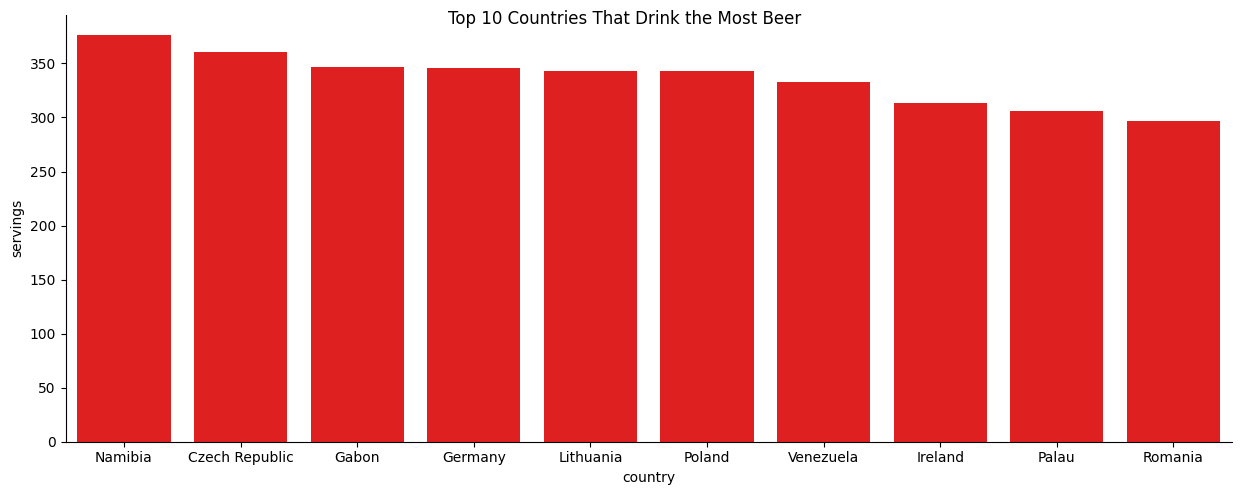

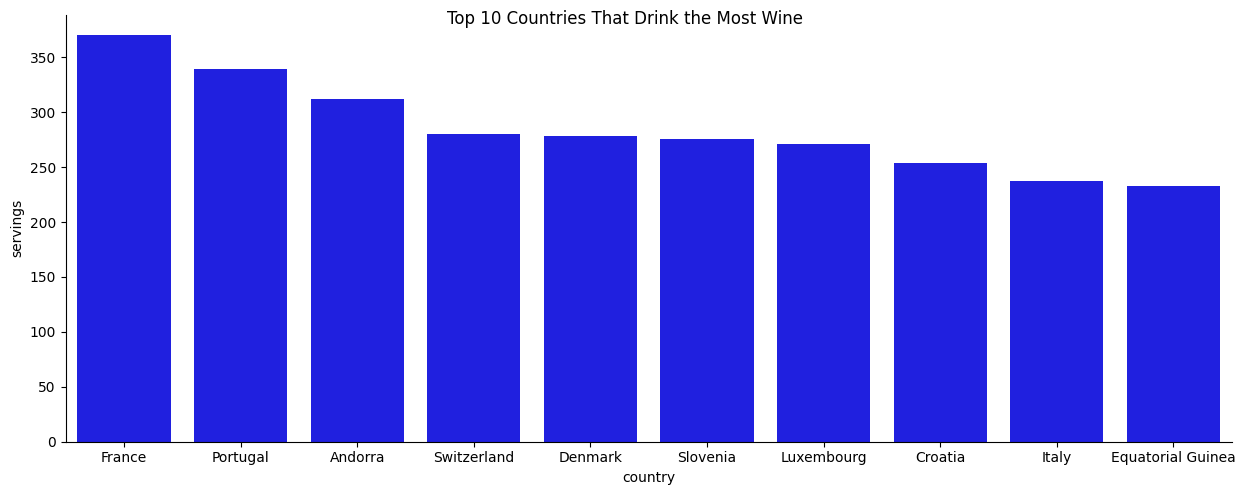

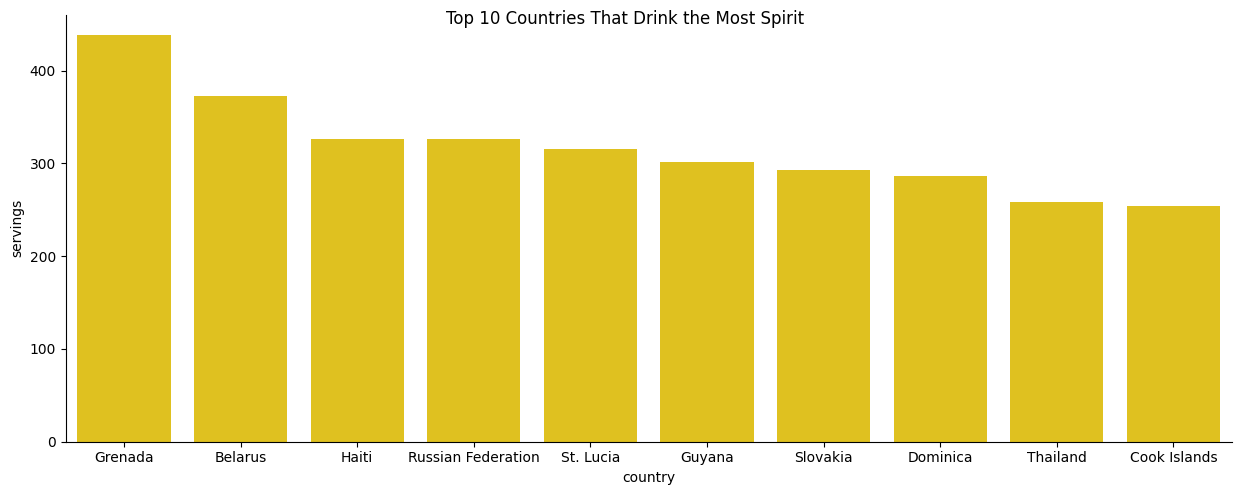

In [7]:
# Remove "_servings" from tidy_alcohol
tidy_alcohol.drink = tidy_alcohol.drink.str.replace("_servings", "")

most_beer = sns.catplot(
    data=tidy_alcohol[tidy_alcohol.drink == "beer"].sort_values(by="servings", ascending=False).head(10),
    x="country",
    y="servings",
    kind="bar",
    color="red",
    aspect=2.5
)
most_beer.fig.suptitle("Top 10 Countries That Drink the Most Beer")

most_wine = sns.catplot(
    data=tidy_alcohol[tidy_alcohol.drink == "wine"].sort_values(by="servings", ascending=False).head(10),
    x="country",
    y="servings",
    kind="bar",
    color="blue",
    aspect=2.5
)
most_wine.fig.suptitle("Top 10 Countries That Drink the Most Wine")

most_spirit = sns.catplot(
    data=tidy_alcohol[tidy_alcohol.drink == "spirit"].sort_values(by="servings", ascending=False).head(10),
    x="country",
    y="servings",
    kind="bar",
    color="gold",
    aspect=2.5
)
most_spirit.fig.suptitle("Top 10 Countries That Drink the Most Spirit")

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [8]:
pd.pivot_table(
    data=tidy_alcohol,
    columns=["country", "drink"],
    values="servings"
)

country  Afghanistan             Albania              Algeria               \
drink           beer spirit wine    beer spirit  wine    beer spirit  wine   
servings         0.0    0.0  0.0    89.0  132.0  54.0    25.0    0.0  14.0   

country  Andorra  ... Vietnam Yemen             Zambia             Zimbabwe  \
drink       beer  ...    wine  beer spirit wine   beer spirit wine     beer   
servings   245.0  ...     1.0   6.0    0.0  0.0   32.0   19.0  4.0     64.0   

country               
drink    spirit wine  
servings   18.0  4.0  

[1 rows x 579 columns]